# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [3]:
df = pd.read_csv('student_lifestyle_performance_dataset.csv')

df_sorted = df.sort_values(by='CGPA', ascending=False)

top_15 = df_sorted.head(15)

wynik = top_15[['Age', 'Study_Hours_per_Day', 'Gym_Hours_per_Week', 'Screen_Time_Hours', 'Sleep_Hours']]

display(wynik)

,Age,Study_Hours_per_Day,Gym_Hours_per_Week,Screen_Time_Hours,Sleep_Hours
657,22,6.85,12.67,3.84,8.45
109,23,5.83,6.05,7.19,9.26
843,24,4.64,3.59,3.28,8.34
405,17,6.87,18.13,2.21,7.92
464,25,5.18,7.85,7.92,9.13
171,20,8.05,0.00,6.46,7.34
475,19,5.71,12.96,2.98,8.07
639,19,7.30,8.24,3.96,8.57
659,20,3.85,5.21,7.14,9.22
682,25,4.87,0.00,4.95,8.25


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [4]:
df['Czas_wolny'] = 24 - df['Study_Hours_per_Day'] - df['Screen_Time_Hours']
+ 1 - 2.5 - df['Gym_Hours_per_Week']/7 - df['Sleep_Hours']

df['Czas_wolny'] = df['Czas_wolny'].round(2)

columns = [
    'Study_Hours_per_Day',
    'Gym_Hours_per_Week',
    'Sleep_Hours',
    'Screen_Time_Hours'
]

columns_to_print = ['Czas_wolny'] + columns

table = df[columns_to_print]
display(table)

,Czas_wolny,Study_Hours_per_Day,Gym_Hours_per_Week,Sleep_Hours,Screen_Time_Hours
0,10.63,4.14,2.67,6.84,9.23
1,14.94,5.97,15.61,5.52,3.09
2,15.79,3.19,2.52,3.39,5.02
3,10.02,4.77,0.00,6.44,9.21
4,13.82,5.42,9.93,6.54,4.76
...,...,...,...,...,...
995,15.17,4.60,12.64,5.26,4.23
996,16.10,4.02,2.86,6.55,3.88
997,15.08,4.28,0.00,8.43,4.64
998,12.74,6.42,10.08,6.06,4.84


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [5]:
over_eighteen = df[df['Age'] >= 18]
table_3 = over_eighteen.groupby('Branch').agg(avg_stress_level=('Stress_Level_1_to_10', 'mean'),
median_of_sleep_hours=('Sleep_Hours', 'median')).reset_index()

table_3 = table_3.sort_values(by='avg_stress_level', ascending=False)
display(table_3)


,Branch,avg_stress_level,median_of_sleep_hours
1,Civil,4.630494,6.710
2,ECE,4.626014,6.405
5,Mechanical,4.608940,6.640
3,Electrical,4.544621,6.310
0,CSE,4.526667,6.540
4,IT,4.454929,6.755


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

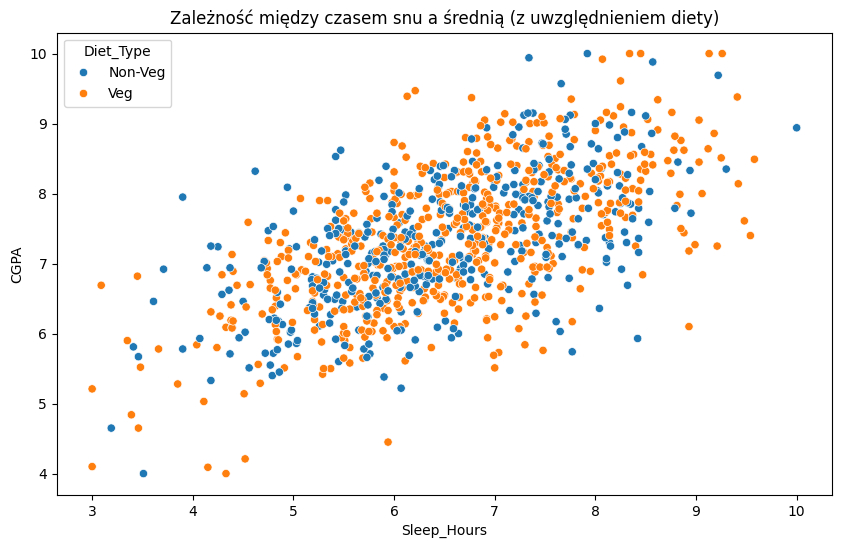

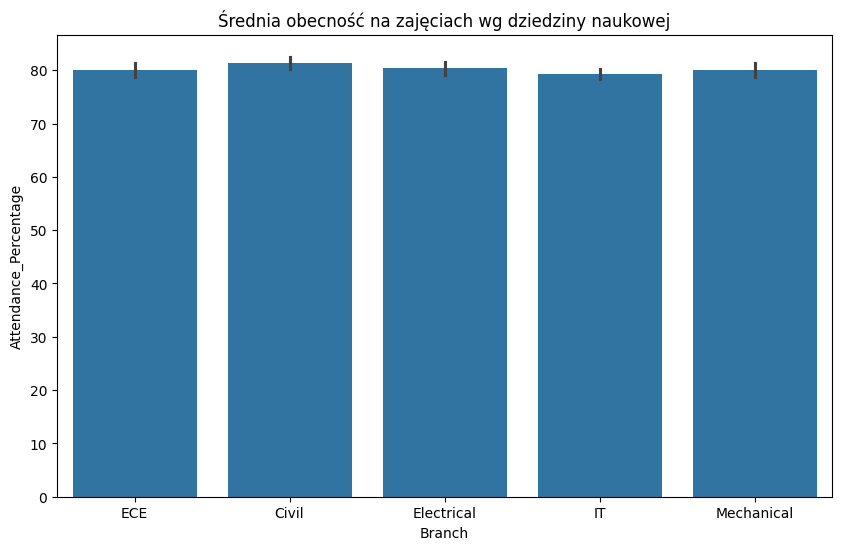

In [6]:
df['Branch'] = df['Branch'].replace('CSE', 'IT')

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Sleep_Hours',
    y='CGPA',
    hue='Diet_Type'
)

plt.title('Zależność między czasem snu a średnią (z uwzględnieniem diety)')
plt.show()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Branch',
    y='Attendance_Percentage'
)

plt.title('Średnia obecność na zajęciach wg dziedziny naukowej')
plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

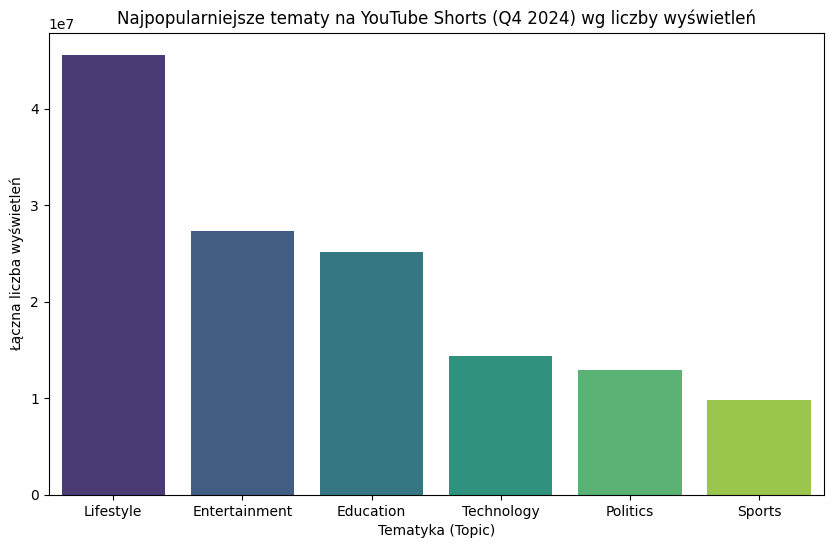

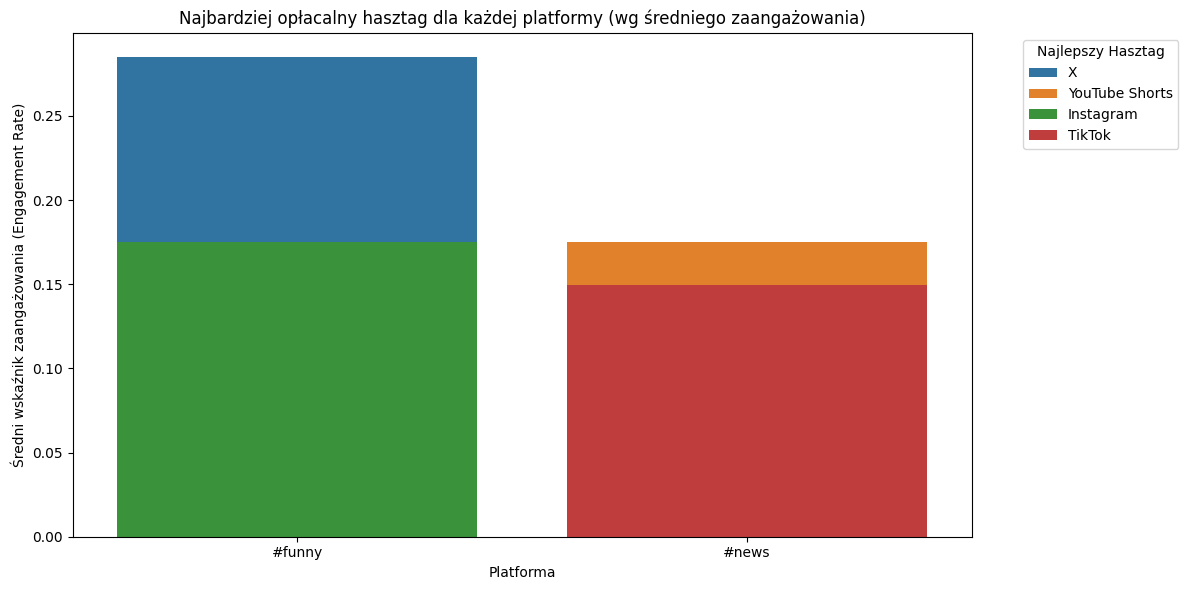

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_social = pd.read_csv('social_media_viral_content_dataset.csv')

df_social['post_datetime'] = pd.to_datetime(df_social['post_datetime'])

maska_q4 = (df_social['post_datetime'] >= '2024-10-01') & (df_social['post_datetime'] <= '2024-12-31')
yt_shorts_q4 = df_social[(df_social['platform'] == 'YouTube Shorts') & maska_q4 & (df_social['content_type'] == 'video')]

tematy_popularnosc = yt_shorts_q4.groupby('topic')['views'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=tematy_popularnosc, x='topic', y='views', hue='topic', palette='viridis', legend=False)
plt.title('Najpopularniejsze tematy na YouTube Shorts (Q4 2024) wg liczby wyświetleń')
plt.xlabel('Tematyka (Topic)')
plt.ylabel('Łączna liczba wyświetleń')
plt.show()

df_hash = df_social.copy()
df_hash['hashtags'] = df_hash['hashtags'].str.split()
df_hash = df_hash.explode('hashtags')
hash_zaangazowanie = df_hash.groupby(['platform', 'hashtags'])['engagement_rate'].mean().reset_index()

najlepsze_hasztagi = hash_zaangazowanie.sort_values('engagement_rate', ascending=False).drop_duplicates(subset=['platform'])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=najlepsze_hasztagi,
    x='hashtags',
    y='engagement_rate',
    hue='platform',
    dodge=False
)
plt.title('Najbardziej opłacalny hasztag dla każdej platformy (wg średniego zaangażowania)')
plt.xlabel('Platforma')
plt.ylabel('Średni wskaźnik zaangażowania (Engagement Rate)')
plt.legend(title='Najlepszy Hasztag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()